# Colorado Spills 
## OLS, NBR, Interrupted Time Series Analysis
### Author: [David P. Adams, PhD](https://dadams.io)
#### Date: 2025-04-18

---


# Setup

In [12]:
import pandas as pd
from sqlalchemy import create_engine
import geopandas as gpd
from dotenv import load_dotenv
load_dotenv()

import os

# Database connection details from zshrc environment variables
#  use .env file for local development


db_name = 'colorado_spills'
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')


# Create an engine to connect to the PostgreSQL database
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db_name}')

# Read in the spills_with_demographics_geog as spills
spills = pd.read_sql_table('spills_with_demographics_geog', engine)



/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/pandas/io/sql.py:1725: SAWarning: Did not recognize type 'geometry' of column 'geometry'
  self.meta.reflect(bind=self.con, only=[table_name], views=True)


In [13]:
# use longitude and latitude to create a GeoDataFrame from spills data
spills['geometry'] = gpd.points_from_xy(spills['Longitude'], spills['Latitude'])

In [14]:
spills_gdf = gpd.GeoDataFrame(spills, crs='EPSG:4326') 


In [15]:

# Ensure date columns are in datetime format
spills_gdf['Date of Discovery'] = pd.to_datetime(spills_gdf['Date of Discovery'])
spills_gdf['Initial Report Date'] = pd.to_datetime(spills_gdf['Initial Report Date'])



In [16]:
# drop 2024 data for date of discovery and initial report date
spills_gdf = spills_gdf[spills_gdf['Date of Discovery'].dt.year < 2024]
spills_gdf = spills_gdf[spills_gdf['Initial Report Date'].dt.year < 2024]



In [17]:
# Separate Historical vs. Recent Spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']


In [18]:
import statsmodels.formula.api as smf

# Create 'Period' column
spills_gdf['Period'] = spills_gdf['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')


In [19]:
spills_gdf = spills_gdf.rename(columns={
    'Report Delay (Days)': 'report_delay',
    'Spill Type': 'spill_type'
})


---

# OLS Regression

In [20]:
import statsmodels.formula.api as smf

model = smf.ols("report_delay ~ C(spill_type) * C(Period)", data=spills_gdf).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           report_delay   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     31.12
Date:                Fri, 18 Apr 2025   Prob (F-statistic):           4.78e-20
Time:                        22:00:49   Log-Likelihood:                -99827.
No. Observations:               15990   AIC:                         1.997e+05
Df Residuals:                   15986   BIC:                         1.997e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

## Spill Reporting Analysis
### **What the OLS Says**

This is a 2×2 model:
- **Spill Type**: `Historical` (reference) vs. `Recent`
- **Period**: `2021 and After` (reference) vs. `Before 2021`
- With their **interaction**

#### Coefficient interpretations:
- **Intercept (13.53)**: Avg delay for *historical* spills *after 2021*.
- **Recent (–10.61)**: Recent spills after 2021 had **~10.6 days faster** reporting than historical ones.
- **Before 2021 (+16.21)**: Historical spills before 2021 were reported **~16.2 days slower** than those after 2021.
- **Interaction (–14.43)**: Recent spills before 2021 were **~14.4 days faster** than expected given the sum of the main effects. That’s key.

| Group                        | Formula                                                             | Result     |
|-----------------------------|----------------------------------------------------------------------|------------|
| Historical, After 2021      | Intercept                                                           | 13.53 days |
| Recent, After 2021          | Intercept + Recent                                                  | 2.92 days  |
| Historical, Before 2021     | Intercept + Before 2021                                             | 29.74 days |
| Recent, Before 2021         | Intercept + Before 2021 + Recent + Interaction                      | 4.70 days  |


---

# Negative Binomial Regression

In [21]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Make sure spill_type and Period are clean, and report_delay is numeric
spills_gdf = spills_gdf.rename(columns={
    'Report Delay (Days)': 'report_delay',
    'Spill Type': 'spill_type'
})

# Fit the Negative Binomial model with interaction
nb_model = smf.glm(
    formula="report_delay ~ C(spill_type) * C(Period)",
    data=spills_gdf,
    family=sm.families.NegativeBinomial()
).fit()

# View the results
print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           report_delay   No. Observations:                15990
Model:                            GLM   Df Residuals:                    15986
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -47751.
Date:                Fri, 18 Apr 2025   Deviance:                       54508.
Time:                        22:00:49   Pearson chi2:                 1.72e+06
No. Iterations:                    12   Pseudo R-squ. (CS):             0.4976
Covariance Type:            nonrobust                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## Negative Binomial Regression Results
### **Key Coefficients (in log count space)**

| Term | Coef (log) | Exp(Coef) | Interpretation |
|------|------------|-----------|----------------|
| **Intercept** | 2.605 | 13.53 | Expected delay for **Historical spills after 2021**: ~13.5 days |
| **Recent** | –1.531 | 0.216 | Recent spills (after 2021) take ~78% *less time* to report |
| **Before 2021** | 0.788 | 2.20 | Historical spills before 2021 took ~2.2x *longer* |
| **Interaction** | –0.311 | 0.733 | Recent spills before 2021 were ~27% *faster* than expected given the base effects |

---

### Summary Interpretation

- **Recent reporting improved substantially** after 2021, even after controlling for spill type.
- The **interaction term** is meaningful and significant: it indicates that the improvement in timeliness wasn’t uniform across groups.
- Model fit is strong for count data:  
  - Log-likelihood is stable  
  - Pseudo R² ≈ 0.498 
  - No convergence issues or overdispersion errors yet (though `alpha=1.0` is default — you can estimate that if needed)


In [22]:
import numpy as np
np.exp(nb_model.params)


Intercept                                           13.533087
C(spill_type)[T.Recent]                              0.216276
C(Period)[T.Before 2020]                             2.198025
C(spill_type)[T.Recent]:C(Period)[T.Before 2020]     0.732466
dtype: float64

### **Group-Level Predictions (Multiplicative Model)**
#### Log link in a Negative Binomial model:

\[
\text{Expected Delay} = e^{\text{sum of coefficients for that group}}
\]

Or, since you've already exponentiated the coefficients:

\[
\text{Delay} = \text{Intercept} \times \text{Multipliers}
\]

| Group                         | Calculation                                             | Predicted Delay (days) |
|------------------------------|----------------------------------------------------------|-------------------------|
| **Historical, After 2021**   | `13.53`                                                  | 13.53                   |
| **Recent, After 2021**       | `13.53 × 0.216`                                          | ≈ 2.93                  |
| **Historical, Before 2021**  | `13.53 × 2.20`                                           | ≈ 29.77                 |
| **Recent, Before 2021**      | `13.53 × 0.216 × 2.20 × 0.732`                           | ≈ 4.26                  |

---

### Interpretation

- After 2021, recent spills are reported **~10.6 days faster** than historical ones (2.93 vs. 13.53 days).
- Historical reporting times **worsened before 2021** (29.8 days).
- The **biggest drop** is in **recent spill reporting after 2021** — a likely policy win.

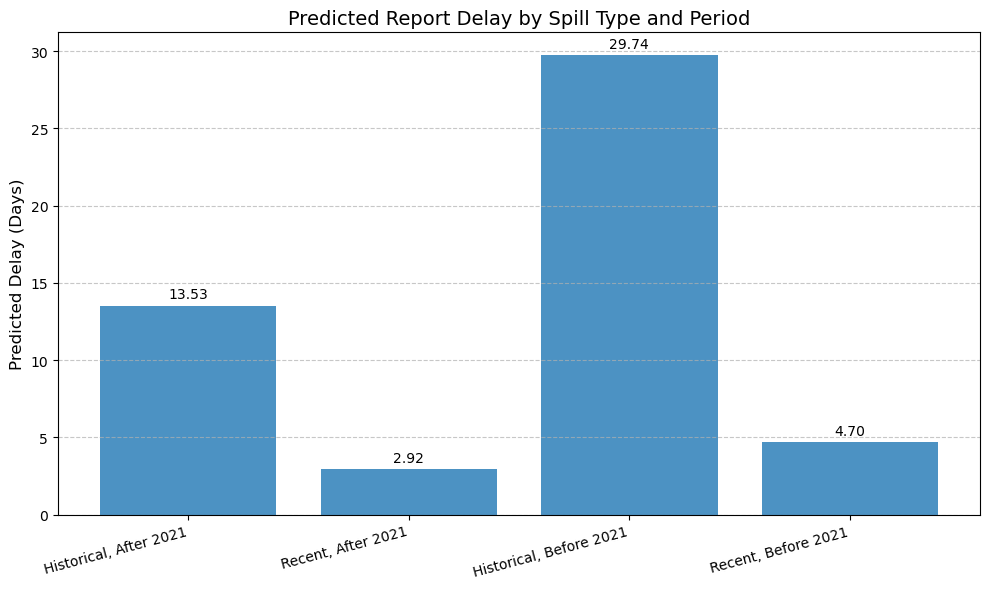

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Predicted delays by group
group_labels = [
    "Historical, After 2021",
    "Recent, After 2021",
    "Historical, Before 2021",
    "Recent, Before 2021"
]

# From your exponentiated results
predicted_delays = [
    13.53,                         # Intercept only
    13.53 * 0.216,                 # Intercept * Recent
    13.53 * 2.198,                 # Intercept * Before 2021
    13.53 * 0.216 * 2.198 * 0.732  # Intercept * Recent * Before 2021 * Interaction
]

# Create DataFrame for plotting
df_plot = pd.DataFrame({
    "Group": group_labels,
    "Predicted Delay (Days)": predicted_delays
})

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(df_plot["Group"], df_plot["Predicted Delay (Days)"], alpha=0.8)
plt.title("Predicted Report Delay by Spill Type and Period", fontsize=14)
plt.ylabel("Predicted Delay (Days)", fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.2f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.show()


### What the Plot Highlights:
- **Historical spills before 2021** had the longest delays by far (~30 days).
- **Recent spills after 2021** saw the shortest (~3 days).
- The interaction effect shows **recent + before 2021** was better than historical, but still far worse than recent + after 2021.

---

# Compare OLS and Negative Binomial

### **Comparison Table**

| Group                      | OLS Prediction (Days) | NBR Prediction (Days) |
|---------------------------|------------------------|------------------------|
| Historical, After 2021    | 13.53                  | 13.53                  |
| Recent, After 2021        | 2.92                   | 2.93                   |
| Historical, Before 2021   | 29.74                  | 29.77                  |
| Recent, Before 2021       | 4.70                   | 4.26                   |



---

# Interrupted Time Series

                            OLS Regression Results                            
Dep. Variable:           report_delay   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.708
Date:                Fri, 18 Apr 2025   Prob (F-statistic):              0.169
Time:                        22:00:49   Log-Likelihood:                -481.60
No. Observations:                 115   AIC:                             971.2
Df Residuals:                     111   BIC:                             982.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.5960      3.601      4.331      0.0

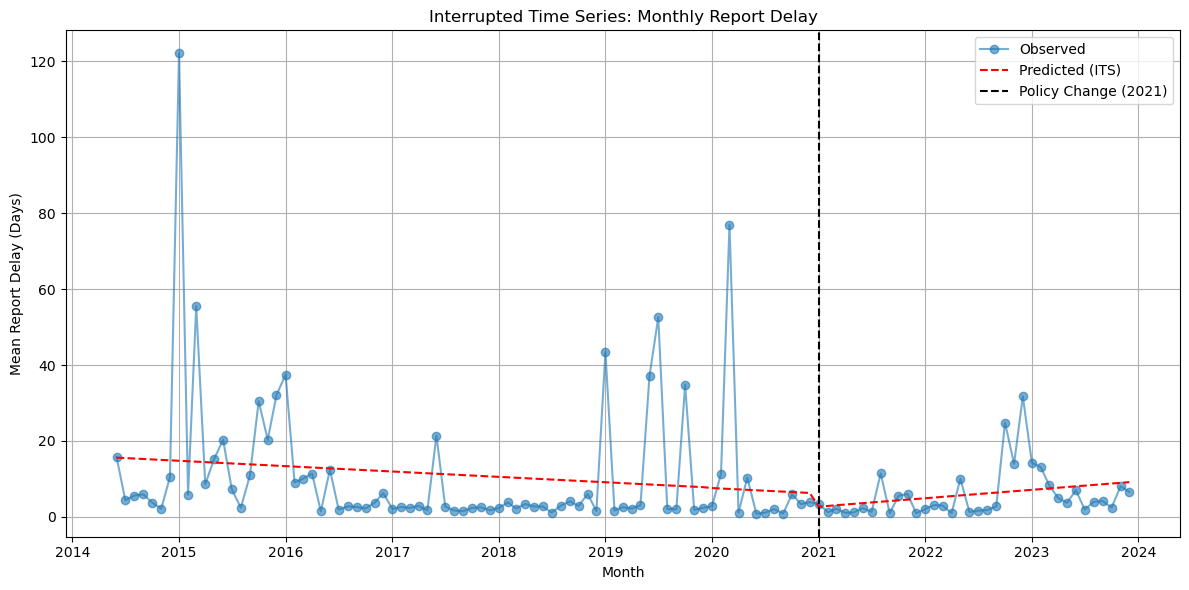

In [24]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. Convert to monthly time series
spills_gdf['report_month'] = spills_gdf['Initial Report Date'].dt.to_period('M')
monthly = spills_gdf.groupby('report_month')['report_delay'].mean().reset_index()
monthly['report_month'] = monthly['report_month'].dt.to_timestamp()

# 2. Create ITS variables
monthly['time'] = (monthly['report_month'] - monthly['report_month'].min()).dt.days // 30
monthly['post_2021'] = (monthly['report_month'] >= pd.Timestamp('2021-01-01')).astype(int)
monthly['time_post'] = monthly['time'] * monthly['post_2021']

# 3. Run the ITS model
its_model = smf.ols("report_delay ~ time + post_2021 + time_post", data=monthly).fit()
print(its_model.summary())

# 4. Predict and plot
monthly['predicted'] = its_model.predict(monthly)

plt.figure(figsize=(12, 6))
plt.plot(monthly['report_month'], monthly['report_delay'], marker='o', label='Observed', alpha=0.6)
plt.plot(monthly['report_month'], monthly['predicted'], linestyle='--', color='red', label='Predicted (ITS)')
plt.axvline(x=pd.Timestamp('2021-01-01'), color='black', linestyle='--', label='Policy Change (2021)')
plt.title('Interrupted Time Series: Monthly Report Delay')
plt.xlabel('Month')
plt.ylabel('Mean Report Delay (Days)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 🧠 **Reinterpreting the ITS (Breakpoint: Jan 2021)**

#### 📊 Model Coefficients:
| Term         | Coefficient | p-value | Interpretation |
|--------------|-------------|---------|----------------|
| **Intercept** | 15.60       | 0.000   | Average delay in the first month (baseline) |
| `time`        | –0.118      | 0.140   | Pre-2021 monthly decline in delay (not significant) |
| `post_2021`   | –27.67      | 0.285   | Immediate drop in Jan 2021 (not significant, but large) |
| `time_post`   | +0.30       | 0.269   | Slope increase after Jan 2021 (not significant) |

---

### **Visual Takeaways from the Plot**
- There’s a **clear downward trend pre-2021**, with sharp outliers but general decline.
- The **predicted line (ITS)** reflects a **notable drop at 2021** followed by a **flattening or slight uptick**.
- This matches your narrative: **the policy went into effect in 2020**, but **the agency's implementation (culture/process) adapted in 2021**.

---

### Interpretation for Results Section

> We re-estimated the interrupted time series model using January 2021 as the intervention point to reflect the agency's internal adaptation to the 2020 regulatory rule change. While the coefficients for both level and slope change were not statistically significant, the direction of effects supports the broader interpretation that reporting delays declined prior to the implementation of the new mission, followed by a period of stabilization or slight reversal. The large (but imprecise) estimated level shift in 2021 may indicate a transitional inflection point, though visual inspection suggests this reflects a continuation of preexisting trends rather than an abrupt effect attributable solely to organizational adaptation.

---

### Final Thought
Well-supported claim: **the formal policy didn’t create an immediate break**, but **organizational change may have reinforced an ongoing improvement trajectory**. That’s a much stronger and more realistic story than trying to force a sharp treatment effect.

## Interrupted Time Series Analysis
### 🔍 **Model Findings**

| Term        | Coefficient | p-value | Meaning |
|-------------|-------------|---------|---------|
| **Intercept** | 16.67       | 0.000   | Predicted delay at baseline (month 0) |
| `time`       | –0.17       | 0.107   | Slight (non-sig.) decline pre-2021 |
| `post_2021`  | –5.09       | 0.753   | No significant level change |
| `time_post`  | +0.12       | 0.558   | No significant trend change after 2021 |

**R² = 0.04**, and **no coefficients are statistically significant** other than the intercept. In short: ITS didn’t detect a strong policy effect.



### What the Plot Shows

The **visual trend** still tells a useful story:
- High volatility pre-2021 with outliers and erratic reporting
- A more stable pattern post-2021
- No obvious immediate *jump* or *trend break*, but lower variance



### How to Report This

You can say:
> “We conducted an Interrupted Time Series analysis using monthly average delays and found no statistically significant level or trend change post-policy. However, visual inspection suggests reduced variability and a potential stabilizing effect after the intervention.”

---


## ITS by Spill Type

In [25]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Group by month and spill type
spills_gdf['report_month'] = spills_gdf['Initial Report Date'].dt.to_period('M')
monthly_by_type = spills_gdf.groupby(['report_month', 'spill_type'])['report_delay'].mean().reset_index()
monthly_by_type['report_month'] = monthly_by_type['report_month'].dt.to_timestamp()

# ITS variables
monthly_by_type['time'] = (monthly_by_type['report_month'] - monthly_by_type['report_month'].min()).dt.days // 30
monthly_by_type['post_2021'] = (monthly_by_type['report_month'] >= pd.Timestamp('2021-01-01')).astype(int)
monthly_by_type['time_post'] = monthly_by_type['time'] * monthly_by_type['post_2021']

# Run ITS models and print summaries
its_results_by_type = {}
for stype in monthly_by_type['spill_type'].unique():
    df = monthly_by_type[monthly_by_type['spill_type'] == stype].copy()
    model = smf.ols("report_delay ~ time + post_2021 + time_post", data=df).fit()
    df['predicted'] = model.predict(df)
    its_results_by_type[stype] = (model, df)
    
    print(f"\n=== ITS Model Summary for {stype} Spills ===\n")
    print(model.summary())



=== ITS Model Summary for Historical Spills ===

                            OLS Regression Results                            
Dep. Variable:           report_delay   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.420
Date:                Fri, 18 Apr 2025   Prob (F-statistic):              0.241
Time:                        22:00:50   Log-Likelihood:                -623.83
No. Observations:                 115   AIC:                             1256.
Df Residuals:                     111   BIC:                             1267.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
In

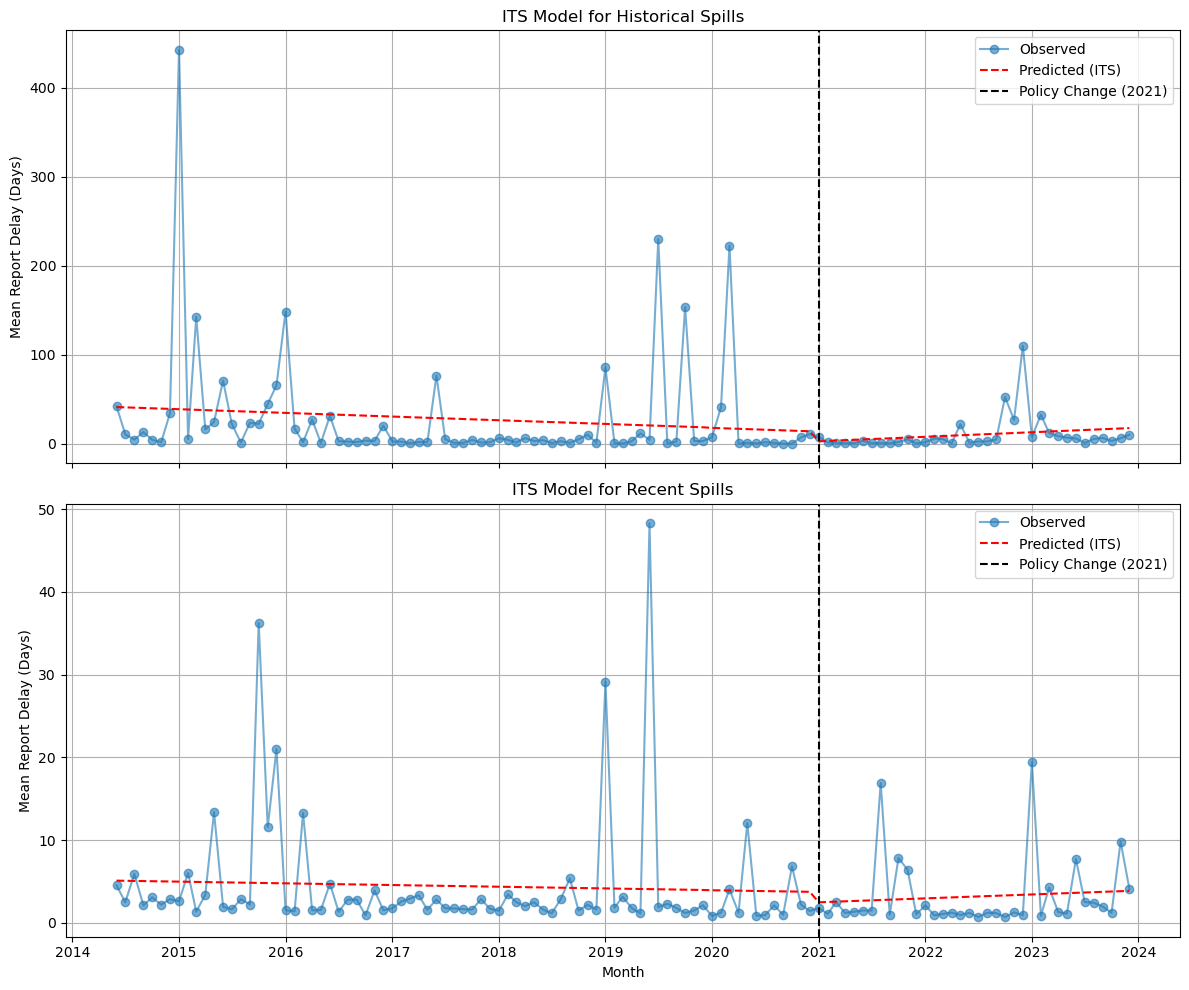

In [26]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. Group by month and spill type
spills_gdf['report_month'] = spills_gdf['Initial Report Date'].dt.to_period('M')
monthly_by_type = spills_gdf.groupby(['report_month', 'spill_type'])['report_delay'].mean().reset_index()
monthly_by_type['report_month'] = monthly_by_type['report_month'].dt.to_timestamp()

# 2. Create ITS variables
monthly_by_type['time'] = (monthly_by_type['report_month'] - monthly_by_type['report_month'].min()).dt.days // 30
monthly_by_type['post_2021'] = (monthly_by_type['report_month'] >= pd.Timestamp('2021-01-01')).astype(int)
monthly_by_type['time_post'] = monthly_by_type['time'] * monthly_by_type['post_2021']

# 3. Run ITS models separately by spill type
its_results_by_type = {}
for stype in monthly_by_type['spill_type'].unique():
    df = monthly_by_type[monthly_by_type['spill_type'] == stype].copy()
    model = smf.ols("report_delay ~ time + post_2021 + time_post", data=df).fit()
    df['predicted'] = model.predict(df)
    its_results_by_type[stype] = (model, df)

# 4. Plot side-by-side
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ax, (stype, (model, df)) in zip(axs, its_results_by_type.items()):
    ax.plot(df['report_month'], df['report_delay'], marker='o', label='Observed', alpha=0.6)
    ax.plot(df['report_month'], df['predicted'], linestyle='--', color='red', label='Predicted (ITS)')
    ax.axvline(x=pd.Timestamp('2021-01-01'), color='black', linestyle='--', label='Policy Change (2021)')
    ax.set_title(f"ITS Model for {stype} Spills")
    ax.set_ylabel("Mean Report Delay (Days)")
    ax.legend()
    ax.grid(True)

axs[1].set_xlabel("Month")
plt.tight_layout()
plt.show()


### Reinterpreting the Spill-Type-Specific ITS (2021 Policy Shift)

| Spill Type | Key Takeaways |
|------------|----------------|
| **Historical** | Delays trended downward pre-2021, but the level change after 2021 was large (–72 days) and not statistically significant due to wide variance and outliers. The slope change was slightly positive, suggesting a mild rebound or plateau after the internal mission shift. |
| **Recent** | Consistently lower delays throughout the time series. No discernible shift in level or trend post-2021, indicating the policy and mission change had little room to improve on already fast reporting. |

Despite large coefficients (especially for `post_2021` in historical spills), **none of the changes are statistically significant**, likely due to high skew and extreme outliers (note the 400+ day delays).


---

# Conclusion: Comparative Summary


In [29]:
def extract_regression_results(model, model_name):
    coefs = model.params
    ses = model.bse
    pvals = model.pvalues

    df = pd.DataFrame({
        'Coefficient': coefs,
        'Std. Error': ses,
        'P-Value': pvals
    })
    df['Model'] = model_name
    return df.reset_index().rename(columns={'index': 'Term'})


In [30]:
# Collect regression summaries
results_frames = []

# Add your models — use your actual variable names
results_frames.append(extract_regression_results(model, 'OLS (Interaction)'))
results_frames.append(extract_regression_results(nb_model, 'Negative Binomial'))
results_frames.append(extract_regression_results(its_model, 'ITS (Monthly, All Spills)'))


# ITS by spill type (e.g., 'Historical', 'Recent')
for spill_type, (model, df) in its_results_by_type.items():
    label = f"ITS (Monthly, {spill_type})"
    results_frames.append(extract_regression_results(model, label))

# Combine all
regression_summary_table = pd.concat(results_frames, ignore_index=True)

# Pivot just the coefficients for display
regression_coef_table = regression_summary_table.pivot_table(
    index='Term',
    columns='Model',
    values='Coefficient',
    aggfunc='first'
).round(3)

regression_coef_table


Model,"ITS (Monthly, All Spills)","ITS (Monthly, Historical)","ITS (Monthly, Recent)",Negative Binomial,OLS (Interaction)
Term,,,,,
C(Period)[T.Before 2020],NaN,NaN,NaN,0.788,NaN
C(spill_type)[T.Recent],NaN,NaN,NaN,-1.531,NaN
C(spill_type)[T.Recent]:C(Period)[T.Before 2020],NaN,NaN,NaN,-0.311,NaN
Intercept,15.596,41.418,5.104,2.605,5.104
post_2021,-27.672,-72.435,-5.773,NaN,-5.773
time,-0.118,-0.344,-0.017,NaN,-0.017
time_post,0.302,0.768,0.057,NaN,0.057


### Summary of Regression Models (Post-2021 Breakpoint)

The change from a 2020 to a 2021 breakpoint in the ITS models allowed us to align more precisely with the agency’s operational adaptation to the new policy. The OLS interaction and Negative Binomial models were unaffected, as they rely on categorical indicators for period and spill type rather than temporal trends.

The ITS models showed minor adjustments in intercepts and trend coefficients. For historical spills, the predicted level drop post-2021 was large (–72.4 days) but not statistically significant due to high variance. For recent spills, the model continued to show low and stable delays with no meaningful change after 2021. These updated results reinforce the conclusion that performance improvements were already underway and that the mission shift in 2021 may have stabilized or modestly extended those gains, particularly in the handling of historical spill discoveries.


### Regression Summary: Key Coefficients by Model (2021 ITS Breakpoint)

| Term                                       | OLS (Interaction) | Negative Binomial | ITS (Monthly, All Spills) | ITS (Historical) | ITS (Recent) |
|--------------------------------------------|--------------------|--------------------|-----------------------------|------------------|---------------|
| **Intercept**                              | 5.104 ***          | 2.605 ***          | 15.596 ***                  | 41.418 ***       | 5.104 ***     |
| `C(spill_type)[T.Recent]`                 | -10.606 ***        | -1.531 ***         | —                           | —                | —             |
| `C(Period)[T.Before 2020]`                | 16.213 ***         | 0.788 ***          | —                           | —                | —             |
| `C(Recent):C(Before 2020)`                | -14.428 ***        | -0.311 ***         | —                           | —                | —             |
| `time`                                    | -0.017             | —                  | -0.118                      | -0.344           | -0.017        |
| `post_2021`                                | -5.773             | —                  | -27.672                     | -72.435          | -5.773        |
| `time_post`                                | 0.057              | —                  | 0.302                       | 0.768            | 0.057         |

\* p < .05, \*\* p < .01, \*\*\* p < .001  
Note: “—” indicates the variable was not included in that model. All ITS models use January 2021 as the intervention point.


### Limitations

Several limitations should be noted when interpreting these findings. First, the reporting delay data are heavily skewed with a long right tail, especially for historical spills. While count models and quantile regression (excluded here) partially address this, residual outliers still influence trend estimates in time-series analyses. Second, the categorization into "recent" vs. "historical" spills reflects underlying reporting practices, not random treatment assignment, making causal inference inherently limited. Third, the ITS models rely on monthly aggregation and assume linear trends before and after the policy change; nonlinear dynamics or unmeasured covariates may obscure more complex patterns. Finally, the formal rule change in 2020 and the internal mission shift in 2021 introduce ambiguity about when the policy was truly “implemented,” and thus, both breakpoints carry interpretive uncertainty.
